<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/gradient-collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Example


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

def preprocess_image(image):
    # Original image as first input
    original_image = image

    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)

    # Random center offset (normal distribution around center)
    center_x = img_width / 2.0
    center_y = img_height / 2.0
    offset_x = tf.random.normal([], mean=0, stddev=img_width/8)  # Small stddev to stay near center
    offset_y = tf.random.normal([], mean=0, stddev=img_height/8)
    crop_center_x = center_x + offset_x
    crop_center_y = center_y + offset_y

    # Random rotation (normal distribution, mean 0, stddev 45 degrees)
    angle_deg = tf.random.normal([], mean=0.0, stddev=45.0)
    angle_rad = angle_deg * np.pi / 180.0

    # Define the crop window (square of crop_size centered at origin)
    half_crop = crop_size / 2.0
    crop_points = tf.constant([
        [-half_crop, -half_crop],  # Top-left
        [half_crop, -half_crop],   # Top-right
        [half_crop, half_crop],    # Bottom-right
        [-half_crop, half_crop]    # Bottom-left
    ], dtype=tf.float32)

    # Rotate the crop window
    cos_val = tf.cos(angle_rad)
    sin_val = tf.sin(angle_rad)
    rotation_matrix = tf.stack([
        [cos_val, sin_val],
        [-sin_val, cos_val]
    ])
    rotated_points = tf.matmul(crop_points, rotation_matrix)

    # Translate to the crop center
    rotated_points += tf.stack([crop_center_x, crop_center_y])

    # Compute the bounding box of the rotated crop window
    min_x = tf.reduce_min(rotated_points[:, 0])
    max_x = tf.reduce_max(rotated_points[:, 0])
    min_y = tf.reduce_min(rotated_points[:, 1])
    max_y = tf.reduce_max(rotated_points[:, 1])

    # Ensure the crop stays within image bounds
    min_x = tf.clip_by_value(min_x, 0.0, img_width - 1.0)
    max_x = tf.clip_by_value(max_x, 0.0, img_width - 1.0)
    min_y = tf.clip_by_value(min_y, 0.0, img_height - 1.0)
    max_y = tf.clip_by_value(max_y, 0.0, img_height - 1.0)

    # Define the affine transform to extract the rotated crop
    # We need to map the rotated crop window to a crop_size x crop_size output
    src_points = tf.stack([
        [min_x, min_y],  # Top-left
        [max_x, min_y],  # Top-right
        [min_x, max_y]   # Bottom-left
    ])
    dst_points = tf.constant([
        [0.0, 0.0],           # Top-left
        [crop_size - 1, 0.0], # Top-right
        [0.0, crop_size - 1]  # Bottom-left
    ], dtype=tf.float32)

    # Compute the affine transform matrix
    transform_matrix = tf.linalg.lstsq(src_points, dst_points, l2_regularizer=0.01)
    transform_matrix = tf.concat([transform_matrix, [[0.0], [0.0], [1.0]]], axis=1)  # Homogeneous coords

    # Apply the transform to get the rotated crop
    image_np = image.numpy()  # Convert to NumPy for apply_affine_transform
    rotated_crop_np = tf.keras.preprocessing.image.apply_affine_transform(
        image_np,
        transform_matrix=transform_matrix.numpy()[:2],  # Use only the 2x3 part
        output_shape=(crop_size, crop_size),
        fill_mode='nearest'
    )
    rotated_crop = tf.convert_to_tensor(rotated_crop_np, dtype=tf.float32)

    # Ground-truth transformation: (dx, dy, angle_deg)
    dx = offset_x / img_width   # Normalized offset
    dy = offset_y / img_height  # Normalized offset
    transformation = tf.stack([dx, dy, angle_deg])

    return original_image, rotated_crop, transformation

# Wrap the function for tf.data
def tf_preprocess_image(image):
    original, rotated_crop, transform = tf.py_function(
        func=preprocess_image,
        inp=[image],
        Tout=[tf.float32, tf.float32, tf.float32]
    )
    original.set_shape([32, 32, 3])
    rotated_crop.set_shape([16, 16, 3])  # Crop is 16x16
    transform.set_shape([3])
    return (original, rotated_crop), transform

# Create the dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.map(
    tf_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, rotated_crop), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", rotated_crop.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original[0])
    plt.subplot(1, 2, 2)
    plt.title(f"Rotated Crop\n(dx, dy, angle): {transform[0].numpy()}")
    plt.imshow(rotated_crop[0])
    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


UnknownError: {{function_node __wrapped__IteratorGetNext_output_types_3_device_/job:localhost/replica:0/task:0/device:CPU:0}} InvalidArgumentError: {{function_node __wrapped__ConcatV2_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} ConcatOp : Dimension 0 in both shapes must be equal: shape[0] = [2,2] vs. shape[1] = [3,1] [Op:ConcatV2]
Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 267, in __call__
    return func(device, token, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 145, in __call__
    outputs = self._call(device, args)
              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 152, in _call
    ret = self._func(*args)
          ^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/autograph/impl/api.

In [ ]:
def preprocess_image(image):
    # Original image as first input
    original_image = image

    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    print(f"original_image: {original_image.shape}, {img_height=}, {img_width=}, {crop_size=}")

    # Random center offset (normal distribution around center)
    center_x = img_width / 2.0
    center_y = img_height / 2.0
    offset_x = tf.random.normal([], mean=0, stddev=img_width/8)  # Small stddev to stay near center
    offset_y = tf.random.normal([], mean=0, stddev=img_height/8)
    crop_center_x = center_x + offset_x
    crop_center_y = center_y + offset_y

    # Random rotation (normal distribution, mean 0, stddev 45 degrees)
    angle_deg = tf.random.normal([], mean=0.0, stddev=45.0)
    angle_rad = angle_deg * np.pi / 180.00
    print(f"center: ({center_x}, {center_y}), offset: ({offset_x}, {offset_y}), crop_centre: {crop_center_x.numpy(), crop_center_y.numpy()}")

    # Define the crop window (square of crop_size centered at origin)
    half_crop = crop_size / 2.0
    crop_points = tf.constant([
        [-half_crop, -half_crop],  # Top-left
        [half_crop, -half_crop],   # Top-right
        [half_crop, half_crop],    # Bottom-right
        [-half_crop, half_crop]    # Bottom-left
    ], dtype=tf.float32)
    print(f"crop_points: {crop_points}")

    # Rotate the crop window
    cos_val = tf.cos(angle_rad)
    sin_val = tf.sin(angle_rad)
    rotation_matrix = tf.stack([
        [cos_val, sin_val],
        [-sin_val, cos_val]
    ])
    rotated_points = tf.matmul(crop_points, rotation_matrix)
    print(f"rotated_points: {rotated_points}")

    # Translate to the crop center
    rotated_points += tf.stack([crop_center_x, crop_center_y])
    print(f"rotated_points after translation: {rotated_points}")

    # Compute the bounding box of the rotated crop window
    min_x = tf.reduce_min(rotated_points[:, 0])
    max_x = tf.reduce_max(rotated_points[:, 0])
    min_y = tf.reduce_min(rotated_points[:, 1])
    max_y = tf.reduce_max(rotated_points[:, 1])
    print(f"bounding box: ({min_x}, {min_y}) - ({max_x}, {max_y})")

    # Ensure the crop stays within image bounds
    min_x = tf.clip_by_value(min_x, 0.0, img_width - 1.0)
    max_x = tf.clip_by_value(max_x, 0.0, img_width - 1.0)
    min_y = tf.clip_by_value(min_y, 0.0, img_height - 1.0)
    max_y = tf.clip_by_value(max_y, 0.0, img_height - 1.0)
    print(f"cropped: ({min_x}, {min_y}) - ({max_x}, {max_y})")

    # Define the affine transform to extract the rotated crop
    # We need to map the rotated crop window to a crop_size x crop_size output
    src_points = tf.stack([
        [min_x, min_y],  # Top-left
        [max_x, min_y],  # Top-right
        [min_x, max_y]   # Bottom-left
    ])
    dst_points = tf.constant([
        [0.0, 0.0],           # Top-left
        [crop_size - 1, 0.0], # Top-right
        [0.0, crop_size - 1]  # Bottom-left
    ], dtype=tf.float32)
    print(f"{src_points=}, {dst_points=}")

    # Compute the affine transform matrix
    transform_matrix = tf.linalg.lstsq(src_points, dst_points, l2_regularizer=0.01)
    transform_matrix = tf.concat([transform_matrix, [[0.0], [0.0], [1.0]]], axis=1)  # Homogeneous coords
    print(f"{transform_matrix=}")

    # Apply the transform to get the rotated crop
    image_np = image.numpy()  # Convert to NumPy for apply_affine_transform
    rotated_crop_np = tf.keras.preprocessing.image.apply_affine_transform(
        image_np,
        transform_matrix=transform_matrix.numpy()[:2],  # Use only the 2x3 part
        output_shape=(crop_size, crop_size),
        fill_mode='nearest'
    )
    rotated_crop = tf.convert_to_tensor(rotated_crop_np, dtype=tf.float32)

    # Ground-truth transformation: (dx, dy, angle_deg)
    dx = offset_x / img_width   # Normalized offset
    dy = offset_y / img_height  # Normalized offset
    transformation = tf.stack([dx, dy, angle_deg])

    return original_image, rotated_crop, transformation

tf.random.set_seed(32)
preprocess_image(x_train[0])

original_image: (32, 32, 3), img_height=32, img_width=32, crop_size=16
center: (16.0, 16.0), offset: (3.281350612640381, 1.6131236553192139), crop_centre: (19.281351, 17.613123)
crop_points: [[-8. -8.]
 [ 8. -8.]
 [ 8.  8.]
 [-8.  8.]]
rotated_points: [[-11.231145    1.3643246]
 [ -1.3643246 -11.231145 ]
 [ 11.231145   -1.3643246]
 [  1.3643246  11.231145 ]]
rotated_points after translation: [[ 8.050206 18.977448]
 [17.917027  6.381978]
 [30.512497 16.248798]
 [20.645676 28.844269]]
bounding box: (8.050206184387207, 6.3819780349731445) - (30.512496948242188, 28.844268798828125)
cropped: (8.050206184387207, 6.3819780349731445) - (30.512496948242188, 28.844268798828125)
src_points=<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 8.050206,  6.381978],
       [30.512497,  6.381978],
       [ 8.050206, 28.844269]], dtype=float32)>, dst_points=<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 0.,  0.],
       [15.,  0.],
       [ 0., 15.]], dtype=float32)>


InvalidArgumentError: {{function_node __wrapped__ConcatV2_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} ConcatOp : Dimension 0 in both shapes must be equal: shape[0] = [2,2] vs. shape[1] = [3,1] [Op:ConcatV2]

In [ ]:
next(iter(train_dataset.take(1)))

UnknownError: {{function_node __wrapped__IteratorGetNext_output_types_3_device_/job:localhost/replica:0/task:0/device:CPU:0}} InvalidArgumentError: {{function_node __wrapped__ConcatV2_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} ConcatOp : Dimension 0 in both shapes must be equal: shape[0] = [2,2] vs. shape[1] = [3,1] [Op:ConcatV2]
Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 267, in __call__
    return func(device, token, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 145, in __call__
    outputs = self._call(device, args)
              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 152, in _call
    ret = self._func(*args)
          ^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/autograph/impl/api.

Original shape: (32, 32, 32, 3)
Rotated Crop shape: (32, 16, 16, 3)
Transformation shape: (32, 3)


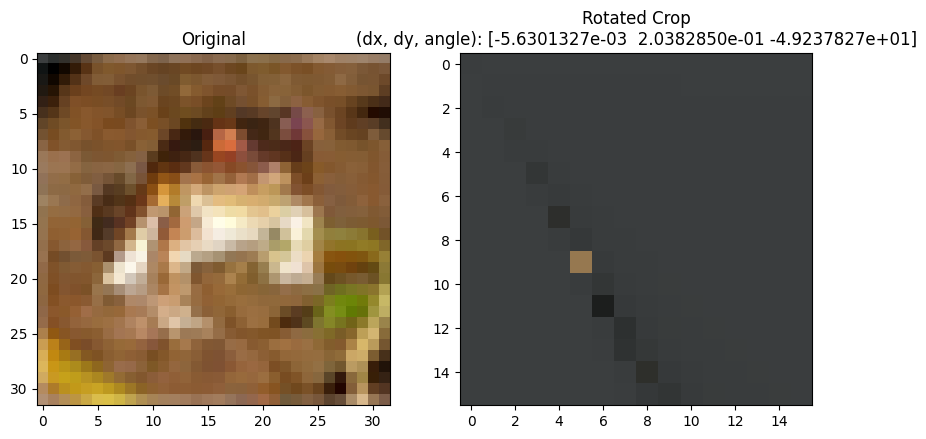

Time for 100 batches: 1.08 seconds


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

def preprocess_image(image):
    # Original image as first input
    original_image = image

    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)

    # Random center offset (normal distribution around center)
    center_x = img_width / 2.0
    center_y = img_height / 2.0
    offset_x = tf.random.normal([], mean=0, stddev=img_width/8)
    offset_y = tf.random.normal([], mean=0, stddev=img_height/8)
    crop_center_x = center_x + offset_x
    crop_center_y = center_y + offset_y

    # Random rotation (normal distribution, mean 0, stddev 45 degrees)
    angle_deg = tf.random.normal([], mean=0.0, stddev=45.0)
    angle_rad = angle_deg * np.pi / 180.0

    # Define the crop window (square of crop_size centered at origin)
    half_crop = crop_size / 2.0
    crop_points = tf.constant([
        [-half_crop, -half_crop],  # Top-left
        [half_crop, -half_crop],   # Top-right
        [half_crop, half_crop],    # Bottom-right
        [-half_crop, half_crop]    # Bottom-left
    ], dtype=tf.float32)

    # Rotate the crop window
    cos_val = tf.cos(angle_rad)
    sin_val = tf.sin(angle_rad)
    rotation_matrix = tf.stack([
        [cos_val, sin_val],
        [-sin_val, cos_val]
    ])
    rotated_points = tf.matmul(crop_points, rotation_matrix)

    # Translate to the crop center
    rotated_points += tf.stack([crop_center_x, crop_center_y])

    # Source points (rotated crop window in original image)
    src_points = rotated_points[:3]  # Use 3 points for affine-like transform

    # Destination points (target 16x16 crop)
    dst_points = tf.constant([
        [0.0, 0.0],           # Top-left
        [crop_size - 1, 0.0], # Top-right
        [0.0, crop_size - 1]  # Bottom-left
    ], dtype=tf.float32)

    # Compute the homography matrix (8 parameters)
    # Pad points to homogeneous coordinates (x, y, 1)
    src_points_h = tf.pad(src_points, [[0, 0], [0, 1]], constant_values=1.0)
    dst_points_h = tf.pad(dst_points, [[0, 0], [0, 1]], constant_values=1.0)

    # Solve for homography using least squares
    h_matrix = tf.linalg.lstsq(src_points_h, dst_points_h, l2_regularizer=0.01)
    h_matrix = tf.reshape(h_matrix, [9])[:8]  # Flatten to 8 params (last is 1)

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='REFLECT'
    )[0]  # Remove batch dimension

    # Ground-truth transformation: (dx, dy, angle_deg)
    dx = offset_x / img_width   # Normalized offset
    dy = offset_y / img_height  # Normalized offset
    transformation = tf.stack([dx, dy, angle_deg])

    return original_image, rotated_crop, transformation

# Define the tf.data mapping function (no tf.py_function needed!)
def tf_preprocess_image(image):
    original, rotated_crop, transform = preprocess_image(image)
    return (original, rotated_crop), transform

# Create the dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.map(
    tf_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, rotated_crop), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", rotated_crop.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original[0])
    plt.subplot(1, 2, 2)
    plt.title(f"Rotated Crop\n(dx, dy, angle): {transform[0].numpy()}")
    plt.imshow(rotated_crop[0])
    plt.show()

# Optional: Time the pipeline
import time
start = time.time()
for _ in train_dataset.take(100):  # Process 100 batches
    pass
print(f"Time for 100 batches: {time.time() - start:.2f} seconds")

original_image: (32, 32, 3), img_height=32, img_width=32, crop_size=16
center: (16.0, 16.0), offset: (1.3607529401779175, 3.204096555709839), crop_centre: (17.360752, 19.204096)
rotation: angle_deg=<tf.Tensor: shape=(), dtype=float32, numpy=-5.947076797485352>, angle_rad=<tf.Tensor: shape=(), dtype=float32, numpy=-0.10379607230424881>
h_matrix=<tf.Tensor: shape=(8,), dtype=float32, numpy=
array([ 0.994618  ,  0.10360979,  1.3607521 , -0.10360979,  0.994618  ,
        3.2040958 ,  0.        ,  0.        ], dtype=float32)>


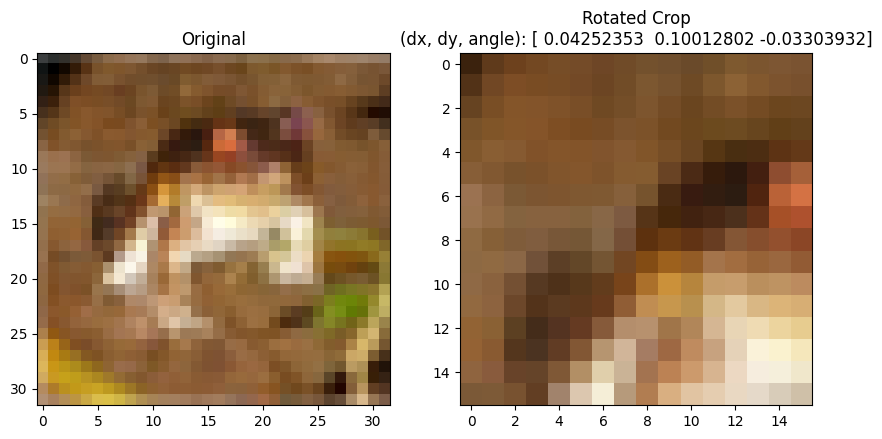

In [25]:
import tensorflow as tf
import numpy as np

def preprocess_image(image):
    # Original image as first input
    original_image = image

    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    print(f"original_image: {original_image.shape}, {img_height=}, {img_width=}, {crop_size=}")

    # Random center offset (normal distribution around center)
    center_x = img_width / 2.0
    center_y = img_height / 2.0
    offset_x = tf.random.normal([], mean=0, stddev=img_width/8)
    offset_y = tf.random.normal([], mean=0, stddev=img_height/8)
    #offset_x, offset_y = tf.constant(5.0), tf.constant(0.0)  # FORCE value for debugging
    crop_center_x = center_x + offset_x
    crop_center_y = center_y + offset_y
    print(f"center: ({center_x}, {center_y}), offset: ({offset_x}, {offset_y}), crop_centre: {crop_center_x.numpy(), crop_center_y.numpy()}")

    # Random rotation (normal distribution, mean 0, stddev 45 degrees)
    angle_deg = tf.random.normal([], mean=0.0, stddev=45.0/8)
    #angle_deg = -45.0  # FORCE value for debugging
    angle_rad = angle_deg * np.pi / 180.0
    print(f"rotation: {angle_deg=}, {angle_rad=}")

    # Directly compute the homography matrix from translation and rotation
    cos_val = tf.cos(angle_rad)
    sin_val = tf.sin(angle_rad)
    tx = crop_center_x - center_x
    ty = crop_center_y - center_y

    h_matrix = tf.stack([
        [cos_val, -sin_val, tx],
        [sin_val, cos_val, ty],
        [0.0, 0.0, 1.0]
    ])

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    print(f"{h_matrix=}")

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    # Ground-truth transformation: (dx, dy, angle_deg)
    dx = offset_x / img_width   # Normalized offset
    dy = offset_y / img_height  # Normalized offset
    da = angle_rad / np.pi  # Normalized angle
    transformation = tf.stack([dx, dy, da])

    return original_image, rotated_crop, transformation

#tf.random.set_seed(32)
orig = x_train[0]
orig2, cropped, transform = preprocess_image(orig)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(orig)
plt.subplot(1, 2, 2)
plt.title(f"Rotated Crop\n(dx, dy, angle): {transform.numpy()}")
plt.imshow(cropped)
plt.show()
